In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.optimize import brentq  # For robust root-finding
from scipy.stats import norm


import sys 
sys.path.append('../')
from bin.dbm import DBManager
from bin.main import Manager 
from bin.options.bsm.bs import bs_df
from anderson_huge import agg_by_strike, get_front_month_chain, andreasen_huge_fit, ah_fit_vega, andreasen_huge_fit_exposure, filter_otm_options
from density.heston_calibrator import HestonCalibrator, FlowAwarePDF, FlowData
from density.pipe import preprocess_option_chain, get_front_month_chain

2026-03-02 20:41:01 - INFO - Loaded 19 database connections from environment
2026-03-02 20:41:01 - ERROR - Ticker file not found: data/stocks/tickers.json
2026-03-02 20:41:01 - WARNING - Failed to load tickers: [Errno 2] No such file or directory: 'data/stocks/tickers.json'


### Import Data
---

In [34]:
dbm = DBManager().for_notebook()
manager = Manager(dbm = dbm)
stock = manager.get_stock_data('smci')
price_data = stock.price_data.daily_df
# option_chain =  stock.options.option_chain_on(chain_date = '2026-02-20', use_cache = False)
option_chain = stock.options.chain_df

2026-03-02 21:00:14 - INFO - Loaded 19 database connections from environment
2026-03-02 21:00:14 - INFO - All connections cleared
2026-03-02 21:00:14 - INFO - Loaded 19 database connections from environment


In [35]:
ochain = bs_df(option_chain)
dtes = list(ochain.gatherdate.unique())
ochain = ochain[ochain.gatherdate == dtes[-1]]
gcdf = preprocess_option_chain(ochain, expiry = 0)
print(gcdf.columns)
r = 0.0405
q = 0.00
S0 = gcdf['stk_price'].iloc[-1]
tau = gcdf['timevalue'].mean()
strikes = gcdf['strike'].values
market_prices = gcdf['lastprice'].values
bs_model_prices = gcdf['fairvalue'].values
actual_ivs = gcdf['impliedvolatility'].values
gamma_exposure = gcdf['gexp'].values
charm_exposure = gcdf['cexp'].values
vanna_exposure = gcdf['vexp'].values
volume = gcdf['volume'].values
openinterest = gcdf['openinterest'].values
oi_chg = gcdf['oi_chg'].values

Found 1 gather dates: [Timestamp('2026-03-02 11:36:06')]
Using expiry at index 0: 2026-03-06 00:00:00
Index(['timevalue', 'strike', 'gexp', 'cexp', 'vexp', 'vega',
       'impliedvolatility', 'volume', 'openinterest', 'oi_chg', 'lastprice',
       'fairvalue', 'stk_price'],
      dtype='object')


## Calibration
----


In [37]:
N, umax = HestonCalibrator.auto_select_params(tau, strikes, S0)
calibrator = HestonCalibrator(N = N, umax = umax)
result = calibrator.calibrate_numba(
    strikes = strikes,
    market_prices = market_prices,
    S0 = S0,
    tau = tau,
    r = r,
    weight_type = 'tail', # 'tail', 'uniform'
    flow_weights = {'gamma': gamma_exposure, 'charm': charm_exposure},
    pop_size = 30,
    max_iter = 100,
)

2026-03-02 21:01:10 - WARNING - Numba not available, falling back to standard calibration
2026-03-02 21:01:10 - INFO - Starting parallel DE calibration (pop=30, iter=100)
2026-03-02 21:01:11 - INFO - DE initial best fitness: 0.411218
2026-03-02 21:01:24 - INFO - DE iteration 20: best=0.367751
2026-03-02 21:01:37 - INFO - DE iteration 40: best=0.366435
2026-03-02 21:01:49 - INFO - DE iteration 60: best=0.365798
2026-03-02 21:02:03 - INFO - DE iteration 80: best=0.365684
2026-03-02 21:02:16 - INFO - DE iteration 100: best=0.365670
2026-03-02 21:02:16 - INFO - Calibration complete. RMSE=0.365670, iter=100


In [41]:
slippage = 0.15
upper = S0 * (1 + slippage)
lower = S0 * (1 - slippage)

print('1. FFT-based PDF:') 
strikes_fft, pdf_fft = calibrator.extract_pdf_fft(
    S0 = S0,
    params = result.params,
    tau = tau,
    r = r,
    q = q
)

valid_fft = (strikes_fft >= lower) & (strikes_fft <= upper)

if np.sum(valid_fft) > 0:
    integral_fft = np.trapz(pdf_fft[valid_fft], strikes_fft[valid_fft])
    peak_idx = np.argmax(pdf_fft[valid_fft])
    print(f'   Integral (70%-130%): {integral_fft:.4f}')
    print(f'   Peak strike: {strikes_fft[valid_fft][peak_idx]:.2f}')
    print(f'   Peak density: {pdf_fft[valid_fft][peak_idx]:.6f}\n')

print('\n2. Price-based PDF (Breeden-Litzenberger):')
strikes_bl, pdf_bl = calibrator.extract_pdf_from_prices(S0, result.params, tau, r, q, n_strikes=100)
valid_bl = (strikes_bl > lower) & (strikes_bl < upper)
if np.sum(valid_bl) > 0:
    integral_bl = np.trapz(pdf_bl[valid_bl], strikes_bl[valid_bl])
    peak_idx = np.argmax(pdf_bl)
    print(f'   Integral (70%-130%): {integral_bl:.4f}')
    print(f'   Peak strike: {strikes_bl[peak_idx]:.2f}')
    print(f'   Peak density: {pdf_bl[peak_idx]:.6f}')

print('\n3. Flow-adjusted PDF:')
flows = FlowData(
    strikes = strikes,
    gex = gamma_exposure,
    vex = vanna_exposure,
    cex = charm_exposure,
    # oi_chg = oi_chg,
    oi_chg = None,
    volume = volume,
)
# apply flow adjustments 
flow_adj = FlowAwarePDF(
    alpha_gex = 0.25,
    alpha_vex = 0.25,
    alpha_cex = 0.05,
    alpha_oi = 0.15,
    mode_bandwidth = 0.1,
    tail_threshold = 0.20
)

pdf_adjusted, components = flow_adj.adjust_pdf(
    strikes = strikes_fft, 
    pdf = pdf_fft,
    S0 = S0,
    flows = flows,
    tau = tau
)

valid_flow = (strikes_fft >= lower) & (strikes_fft <= upper)
key = flow_adj.identify_key_strikes(flows.strikes, flows, S0, n_strikes=3)
pinning = key['pinning']
breakout = key['breakout']
activity = key['high_activity']
if np.sum(valid_flow) > 0:
    integral_flow = np.trapz(pdf_adjusted[valid_flow], strikes_fft[valid_flow])
    peak_idx = np.argmax(pdf_adjusted[valid_flow])
    print(f'   Integral (70%-130%): {integral_flow:.4f}')
    print(f'   Peak strike: {strikes_fft[valid_flow][peak_idx]:.2f}')
    print(f'   Peak density: {pdf_adjusted[valid_flow][peak_idx]:.6f}')
    # Find key strikes
    print(f"      Pinning zones: {key['pinning']}")
    print(f"      Breakout risks: {key['breakout']}")
    print(f"      Key strikes: {key['high_activity']}")


print('\n4. Full-Flow-adjusted PDF (Oi Predictors)')
oi_pred_adjusted_pdf, info = flow_adj.full_flow_adjustment(
    strikes = strikes_fft,
    pdf = pdf_fft,
    S0 = S0,
    tau = tau,
    option_chain = ochain,
    weight_col = 'openinterest'
)
valid_oi_pred = (strikes_fft >= lower) & (strikes_fft <= upper)
if np.sum(valid_oi_pred) > 0:
    integral_oi_pred = np.trapz(oi_pred_adjusted_pdf[valid_oi_pred], strikes_fft[valid_oi_pred])
    peak_idx = np.argmax(oi_pred_adjusted_pdf[valid_oi_pred])
    print(f'   Integral (70%-130%): {integral_oi_pred:.4f}')
    print(f'   Peak strike: {strikes_fft[valid_oi_pred][peak_idx]:.2f}')
    print(f'   Peak density: {oi_pred_adjusted_pdf[valid_oi_pred][peak_idx]:.6f}')


1. FFT-based PDF:
   Integral (70%-130%): 0.9682
   Peak strike: 31.12
   Peak density: 0.286623


2. Price-based PDF (Breeden-Litzenberger):
   Integral (70%-130%): 0.9859
   Peak strike: 30.85
   Peak density: 0.290157

3. Flow-adjusted PDF:
   Integral (70%-130%): 0.5148
   Peak strike: 31.32
   Peak density: 0.144451
      Pinning zones: [33.  32.5 35. ]
      Breakout risks: [30.  31.  30.5]
      Key strikes: [33.  32.5 34.5]

4. Full-Flow-adjusted PDF (Oi Predictors)
   Integral (70%-130%): 0.9974
   Peak strike: 31.12
   Peak density: 0.302081


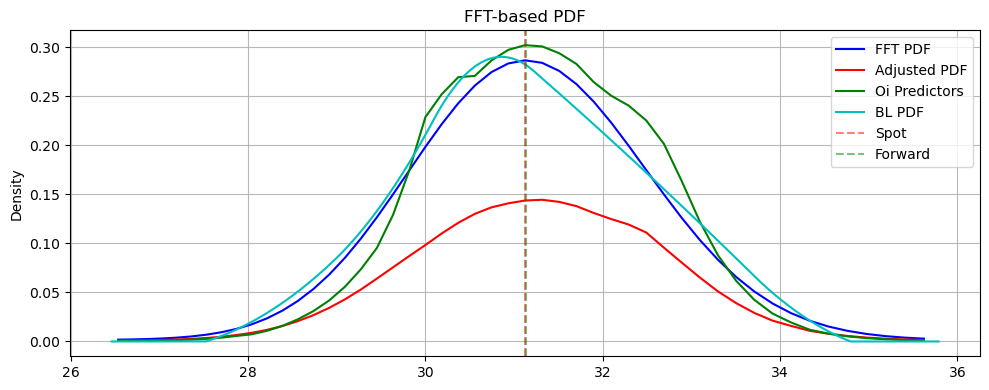

In [42]:
fig, axes = plt.subplots(1, 1, figsize=(10, 4))

ax1 = axes
mask = valid_fft
ax1.plot(strikes_fft[mask], pdf_fft[mask], 'b-', label='FFT PDF')
ax1.plot(strikes_fft[mask], pdf_adjusted[mask], 'r-', label='Adjusted PDF')
ax1.plot(strikes_fft[mask], oi_pred_adjusted_pdf[mask], 'g-', label='Oi Predictors')
ax1.plot(strikes_bl[valid_bl], pdf_bl[valid_bl], 'c-', label='BL PDF')

## Vertical Lines 
ax1.axvline(S0, color='r', linestyle='--', alpha=0.5, label=f'Spot')
ax1.axvline(S0*np.exp(r*tau), color='g', linestyle='--', alpha=0.5, label=f'Forward')

# for p in pinning: ax1.axvline(p, color='blue', alpha=0.25, )
# for b in breakout: ax1.axvline(b, color='red', alpha=0.25)
# for a in activity: ax1.axvline(a, color='purple', alpha=0.25)

ax1.set_ylabel('Density')
ax1.set_title('FFT-based PDF')
ax1.legend()
ax1.grid(True, alpha=0.89)


plt.tight_layout()

In [33]:
# Just pass the option chain directly
chain_df = get_front_month_chain(ochain, 0)
chain_df = bs_df(chain_df)
walls = flow_adj.compute_walls_and_magnet(chain_df, S0, weight_col='volume')
print(f"Call Wall: {walls['call_wall']:.2f} (strength: {walls['call_wall_strength']:.2f})")
print(f"Put Wall: {walls['put_wall']:.2f} (strength: {walls['put_wall_strength']:.2f})")
print(f"Magnet: {walls['magnet']:.2f}")
print(f"Bias: {'Bullish' if walls['directional_bias'] > 0 else 'Bearish'}")

Found 1 gather dates: [Timestamp('2026-03-02 10:33:33')]
Using expiry at index 0: 2026-03-20 00:00:00
Call Wall: 36.86 (strength: 0.82)
Put Wall: 33.09 (strength: 0.92)
Magnet: 36.18
Bias: Bullish
